<a href="https://colab.research.google.com/github/Maheshhikify/AI-Energy_Forecasting_Project/blob/main/Climate_Trend_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Folders Created Successfully ✅
Dataset Generated Successfully ✅
        Date  Temperature    Rainfall   Humidity         CO2
0 2000-01-31    25.496714  108.254163  67.965933  350.000000
1 2000-02-29    24.868167  118.135096  57.443922  350.257235
2 2000-03-31    25.660550  130.375296  55.051976  350.514469
3 2000-04-30    26.542322  120.210038  59.371065  350.771704
4 2000-05-31    24.791570  124.140038  60.278625  351.028939


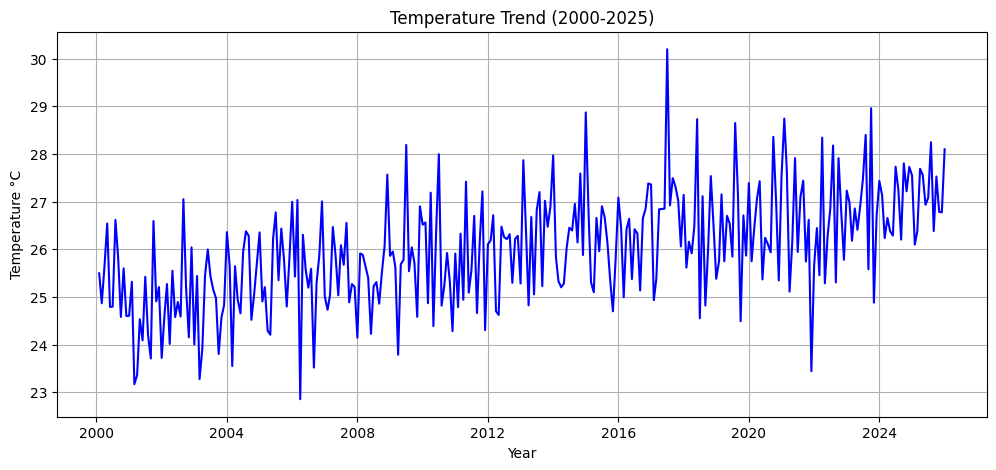

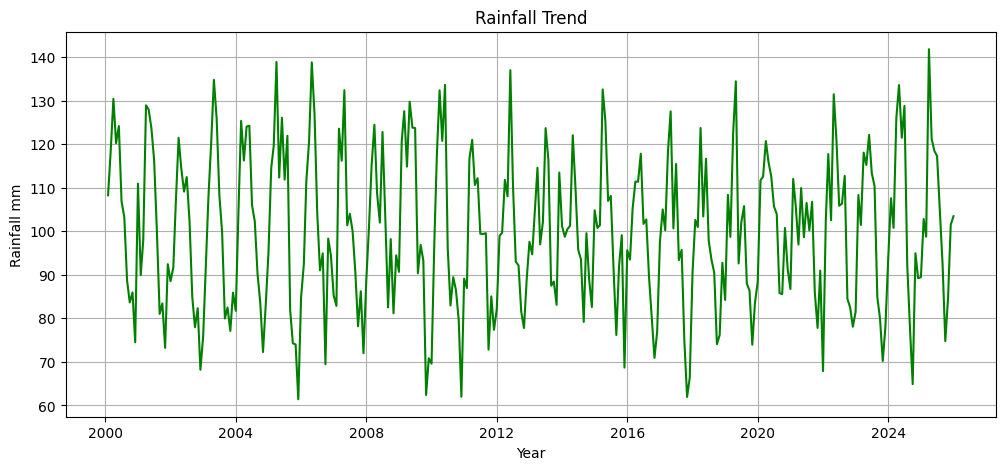

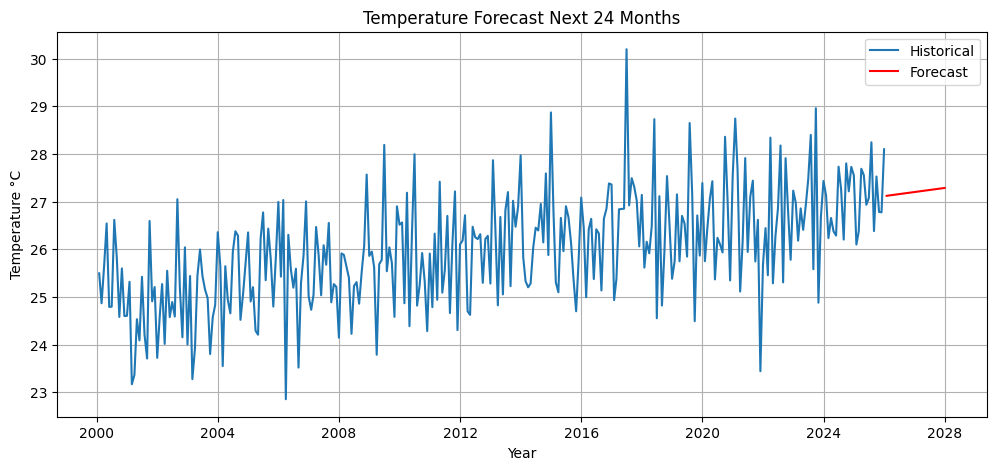

Forecast Completed ✅
README Created ✅


In [2]:

# =========================================
# CLIMATE TREND ANALYZER - FULL PROJECT
# Google Colab Version
# =========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------------------
# 1. CREATE PROJECT FOLDER STRUCTURE
# -----------------------------------------
os.makedirs("Climate-Trend-Analyzer/data/raw", exist_ok=True)
os.makedirs("Climate-Trend-Analyzer/data/processed", exist_ok=True)
os.makedirs("Climate-Trend-Analyzer/outputs/graphs", exist_ok=True)
os.makedirs("Climate-Trend-Analyzer/outputs/reports", exist_ok=True)

print("Folders Created Successfully ✅")

# -----------------------------------------
# 2. GENERATE CLIMATE DATASET
# -----------------------------------------
np.random.seed(42)

dates = pd.date_range(start="2000-01-01", end="2025-12-31", freq="ME")

df = pd.DataFrame()
df["Date"] = dates
df["Temperature"] = 25 + np.linspace(0,2,len(dates)) + np.random.normal(0,1,len(dates))
df["Rainfall"] = 100 + 20*np.sin(np.arange(len(dates))/12*2*np.pi) + np.random.normal(0,10,len(dates))
df["Humidity"] = 60 + np.random.normal(0,5,len(dates))
df["CO2"] = 350 + np.linspace(0,80,len(dates))

df.to_csv("Climate-Trend-Analyzer/data/raw/climate_data.csv", index=False)

print("Dataset Generated Successfully ✅")
print(df.head())

# -----------------------------------------
# 3. TEMPERATURE TREND GRAPH
# -----------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Temperature"], color="blue")
plt.title("Temperature Trend (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Temperature °C")
plt.grid(True)
plt.savefig("Climate-Trend-Analyzer/outputs/graphs/temperature_trend.png")
plt.show()

# -----------------------------------------
# 4. RAINFALL GRAPH
# -----------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Rainfall"], color="green")
plt.title("Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Rainfall mm")
plt.grid(True)
plt.savefig("Climate-Trend-Analyzer/outputs/graphs/rainfall_trend.png")
plt.show()

# -----------------------------------------
# 5. FORECASTING NEXT 24 MONTHS
# -----------------------------------------
X = np.arange(len(df)).reshape(-1,1)
y = df["Temperature"]

model = LinearRegression()
model.fit(X,y)

future = np.arange(len(df), len(df)+24).reshape(-1,1)
forecast = model.predict(future)

future_dates = pd.date_range(start="2026-01-31", periods=24, freq="ME")

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Temperature": forecast
})

forecast_df.to_csv("Climate-Trend-Analyzer/outputs/reports/forecast.csv", index=False)

# Forecast Graph
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Temperature"], label="Historical")
plt.plot(future_dates, forecast, label="Forecast", color="red")
plt.title("Temperature Forecast Next 24 Months")
plt.xlabel("Year")
plt.ylabel("Temperature °C")
plt.legend()
plt.grid(True)
plt.savefig("Climate-Trend-Analyzer/outputs/graphs/forecast_graph.png")
plt.show()

print("Forecast Completed ✅")

# -----------------------------------------
# 6. CREATE README FILE
# -----------------------------------------
readme = """
# Climate Trend Analyzer

## Overview
This project analyzes climate trends using synthetic climate data.

## Features
- Temperature Trend Analysis
- Rainfall Trend Analysis
- Humidity Analysis
- CO2 Increase Trend
- Future Temperature Forecasting

## Tools Used
Python, Pandas, NumPy, Matplotlib, Scikit-learn

## Author
Mahesh
"""

with open("Climate-Trend-Analyzer/README.md","w") as f:
    f.write(readme)

print("README Created ✅")